In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
print(os.path.abspath("house-predict-price.ipynb"))

C:\Users\dell\data-science-ai\house-predict-model\house-predict-price.ipynb


In [5]:
#Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [6]:
#Metrics
from sklearn.metrics import r2_score

In [7]:
df = pd.read_csv(r'C:\Users\dell\data-science-ai\house-predict-model\data\housing_data.csv')

In [8]:
df.head()

,Unnamed: 0,new_price,desc,address,chambres,salles de bains,surface,ascenseur,floor,terrasse,parking,Type,City,Nighberd
0,0,1000000,Appartement traversant de 98 m² au cœur du Bel...,Appartement à vendre Casablanca - Belvédère,2,1,98,Yes,5,Yes,No,Appartement,Casablanca,Belvédère
1,1,1750000,Bureau à vendre de 173 m² à Casablanca – Votre...,Bureau à vendre Casablanca - Autre,1,2,173,Yes,7,Yes,No,Bureau,Casablanca,Autre
2,2,2600000,"Découvrez votre futur chez-vous à Mandarona, C...",Appartement à vendre Casablanca - Californie,3,2,150,Yes,3,Yes,Yes,Appartement,Casablanca,Californie
3,3,2290000,À vendre – Appartement lumineux de 130 m² enti...,Appartement à vendre Casablanca - Les Hôpitaux,2,1,130,Yes,3,No,No,Appartement,Casablanca,Les Hôpitaux
4,4,1460000,Bienvenue dans ce charmant appartement situé d...,Appartement à vendre Meknès - Hamria,3,2,163,Yes,2,No,No,Appartement,Meknès,Hamria


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4675 entries, 0 to 4674
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       4675 non-null   int64
 1   new_price        4675 non-null   int64
 2   desc             4675 non-null   str  
 3   address          4675 non-null   str  
 4   chambres         4675 non-null   int64
 5   salles de bains  4675 non-null   int64
 6   surface          4675 non-null   int64
 7   ascenseur        4675 non-null   str  
 8   floor            4675 non-null   int64
 9   terrasse         4675 non-null   str  
 10  parking          4675 non-null   str  
 11  Type             4675 non-null   str  
 12  City             4675 non-null   str  
 13  Nighberd         4675 non-null   str  
dtypes: int64(6), str(8)
memory usage: 511.5 KB


In [10]:
df = df.drop("Unnamed: 0", axis=1)

In [11]:
df.describe()

,new_price,chambres,salles de bains,surface,floor
count,4.675000e+03,4675.00000,4675.000000,4675.000000,4675.000000
mean,1.871291e+06,2.32000,1.680000,143.720000,3.200000
std,1.348472e+06,1.91269,0.835314,158.579131,1.385789
min,6.770260e+05,1.00000,1.000000,32.000000,1.000000
25%,1.000000e+06,1.00000,1.000000,50.000000,3.000000
50%,1.460000e+06,2.00000,1.000000,83.000000,3.000000
75%,1.794000e+06,3.00000,2.000000,150.000000,4.000000
max,6.800000e+06,10.00000,4.000000,720.000000,7.000000


<Axes: xlabel='chambres', ylabel='new_price'>

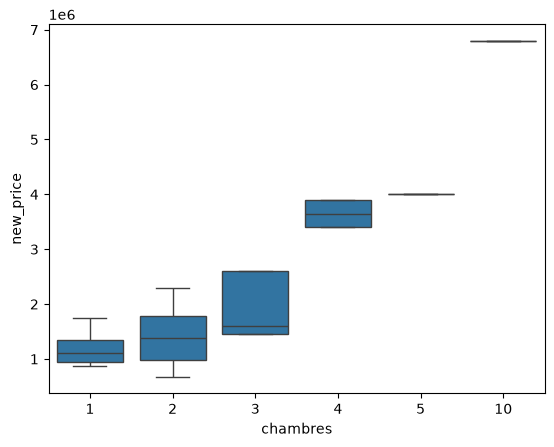

In [12]:
#Creating a boxplot
sns.boxplot(x = 'chambres', y = 'new_price', data = df)

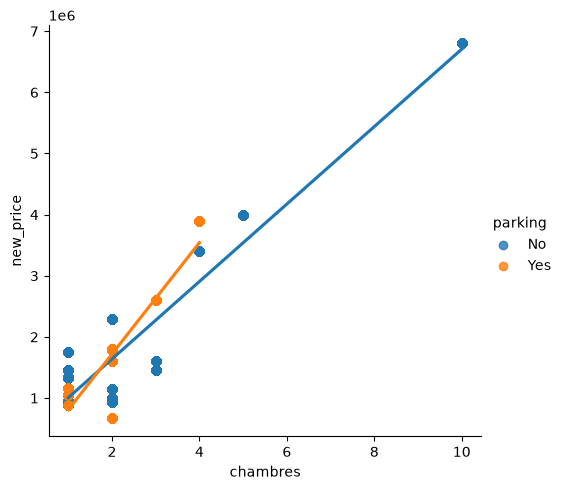

In [13]:
#Creating a linear model plot
sns.lmplot(x ='chambres', y='new_price', hue='parking', data = df)

<Axes: xlabel='Type', ylabel='new_price'>

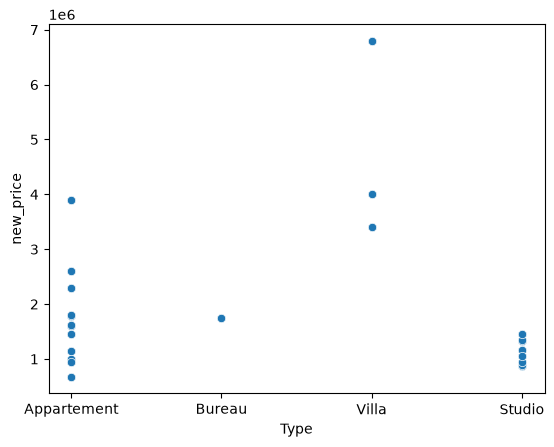

In [14]:
#Creating a scatter plot
sns.scatterplot(x = 'Type', y = 'new_price', data = df)

In [24]:
#Encoding the categorical data 
categorical_columns = df.select_dtypes(['object', 'string']).columns

#Extract all the column names with categorical data
label_encoder = LabelEncoder()

#Go through all columns in the dataframe with categorial data and replace categories with numeric data
for column in categorical_columns :
    temp = label_encoder.fit_transform(df[column])
    df[column] = temp
    df[categorical_columns]

#Checking to see if all the data is in a numeric format
df.dtypes

new_price          int64
desc               int64
address            int64
chambres           int64
salles de bains    int64
surface            int64
ascenseur          int64
floor              int64
terrasse           int64
parking            int64
Type               int64
City               int64
Nighberd           int64
dtype: object

In [25]:
df.describe()

,new_price,desc,address,chambres,salles de bains,surface,ascenseur,floor,terrasse,parking,Type,City,Nighberd
count,4.675000e+03,4675.000000,4675.000000,4675.00000,4675.000000,4675.000000,4675.000000,4675.000000,4675.00000,4675.000000,4675.000000,4675.000000,4675.000000
mean,1.871291e+06,12.000000,9.280000,2.32000,1.680000,143.720000,0.880000,3.200000,0.44000,0.360000,1.120000,1.080000,8.800000
std,1.348472e+06,7.211874,5.488902,1.91269,0.835314,158.579131,0.324996,1.385789,0.49644,0.480051,1.142751,1.787256,5.169692
min,6.770260e+05,0.000000,0.000000,1.00000,1.000000,32.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,1.000000e+06,6.000000,5.000000,1.00000,1.000000,50.000000,1.000000,3.000000,0.00000,0.000000,0.000000,0.000000,4.000000
50%,1.460000e+06,12.000000,10.000000,2.00000,1.000000,83.000000,1.000000,3.000000,0.00000,0.000000,1.000000,0.000000,9.000000
75%,1.794000e+06,18.000000,14.000000,3.00000,2.000000,150.000000,1.000000,4.000000,1.00000,1.000000,2.000000,2.000000,14.000000
max,6.800000e+06,24.000000,18.000000,10.00000,4.000000,720.000000,1.000000,7.000000,1.00000,1.000000,3.000000,6.000000,17.000000


In [32]:
#Spliting data into features and label
x = df.drop(columns = ['new_price']) #Features
y = df['new_price'] #Label

#Splitting the data into Training and Testing data
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 32)
print("Shapes of dataframes: \n",
f'x_train:\t{x_train.shape} \n',
f'x_test:\t{x_test.shape} \n',
f'y_train:\t{y_train.shape} \n',
f'y_test:\t{y_test.shape}')

Shapes of dataframes: 
 x_train:	(3272, 12) 
 x_test:	(1403, 12) 
 y_train:	(3272,) 
 y_test:	(1403,)


In [33]:
#Fitting the data to a Decision Tree Model
dtr = DecisionTreeRegressor()
dtr.fit(x_train, y_train) #Fitting the data
y_pred = dtr.predict(x_test) #Creating a prediction
print(f"{r2_score(y_test, y_pred):.4f}") #Evaluating results

1.0000


In [34]:
print(y_test.values)
print(y_pred)

[1750000 2290000 1790000 ...  950000 1056000  880000]
[1750000. 2290000. 1790000. ...  950000. 1056000.  880000.]


In [35]:
print(len(x_train))
print(len(x_test))

3272
1403
